# 01. 가격 데이터 (계획 1, 3~6단계)

1. 누수 검사
2. 변동성과 급등락(M)
3. 프리마켓 갭 기준선
4. 갭 이후 지속·반전
5. 시장 갭 / 잔차 갭

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import eda_utils as U

U.setup_plot()
pd.set_option("display.float_format", "{:.4f}".format)

panel = U.cached("panel_dev", U.build_panel)

## 1. 누수 검사

패널은 속도를 위해 parquet을 한 번에 읽어 만들었음. 그래서 **day API(src/data.py)로 꺼낸 값과 같은지**를
무작위 날짜로 확인함. 두 열이 모두 0이면 일치하는 것임.

In [2]:
U.check_against_day_api(panel, n_days=8)

,date,n,label_mismatch,gap_max_abs_diff
0,2024-11-27,50,0,0.0000
1,2025-02-13,50,0,0.0000
2,2025-04-02,50,0,0.0000
3,2026-02-26,50,0,0.0000
4,2026-04-09,50,0,0.0000
5,2026-06-05,50,0,0.0000
6,2026-07-13,50,0,0.0000
7,2026-08-14,50,0,0.0000


09:00 pre 봉은 known_at이 정확히 09:30이라 cutoff 경계에 걸림. 규칙은 `known_at < cutoff`라 이 봉은 빠져야 함.
이 봉을 넣으면(`gap_leak`) 상관이 부풀려지는 것을 확인함.

In [3]:
pd.Series({"gap (규칙대로, 08:00 봉까지)": panel[["gap", "ret_t"]].corr().iloc[0, 1],
           "gap_leak (09:00 봉 포함)": panel[["gap_leak", "ret_t"]].corr().iloc[0, 1]},
          name="당일 수익률과의 상관")

gap (규칙대로, 08:00 봉까지)   0.5392
gap_leak (09:00 봉 포함)   0.5789
Name: 당일 수익률과의 상관, dtype: float64

## 2. 변동성과 급등락(M)

### 그림: 구간별 평균 막대그래프 (binned bar chart)
연속 변수 x를 **같은 개수씩 10개 구간(십분위)으로 나누고, 구간마다 y의 평균을 막대로 그린 그림**임.
산점도로는 점이 너무 많아 경향이 안 보일 때 씀. 막대가 왼쪽에서 오른쪽으로 꾸준히 높아지면(단조 증가)
x가 클수록 y도 크다는 뜻임. 여기서 y는 급등락 비율 M임.

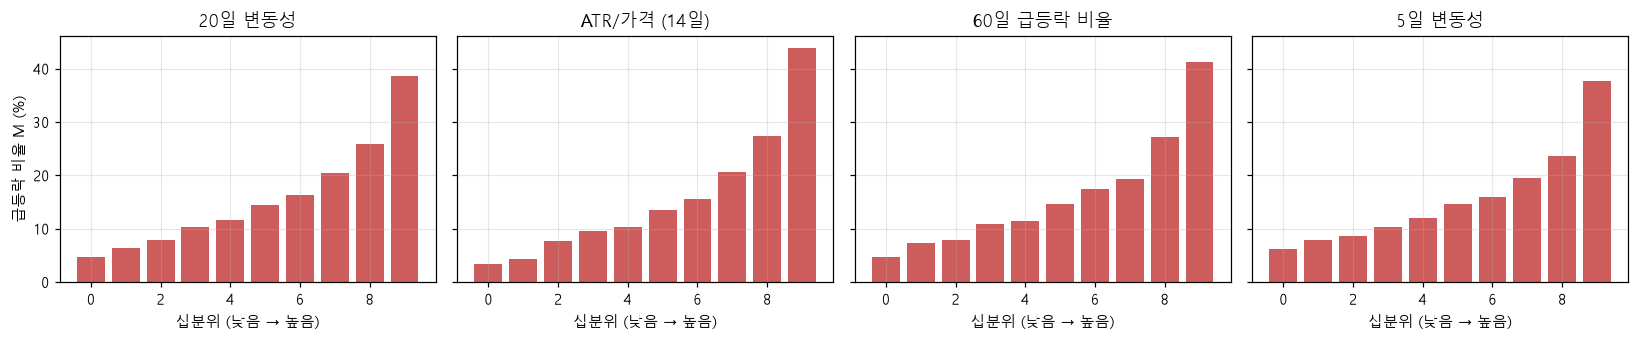

In [4]:
cands = {"vol20": "20일 변동성", "atr14": "ATR/가격 (14일)",
         "big_rate60": "60일 급등락 비율", "vol5": "5일 변동성"}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
for ax, (col, title) in zip(axes, cands.items()):
    b = U.binned(panel, col, "M", q=10)
    ax.bar(range(len(b)), b["M"] * 100, color="indianred")
    ax.set(title=title, xlabel="십분위 (낮음 → 높음)")
axes[0].set_ylabel("급등락 비율 M (%)")
plt.tight_layout()
plt.show()

### 그림: 산점도 (scatter plot)
산점도는 **두 변수를 가로축·세로축에 놓고 관측 하나를 점 하나로 찍은 그림**임.
점들이 오른쪽 위로 몰려 있으면 두 변수가 함께 커지는 관계(양의 상관)임.

여기서 점 하나는 **종목 하나**임. 가로축은 그 종목의 평균 20일 변동성, 세로축은 급등락 비율임.
점들이 한 줄로 늘어서면 "종목 ID" 대신 "변동성"만 알아도 그 종목의 급등락 경향을 알 수 있다는 뜻이고,
처음 보는 종목에도 일반화할 수 있다는 근거가 됨.

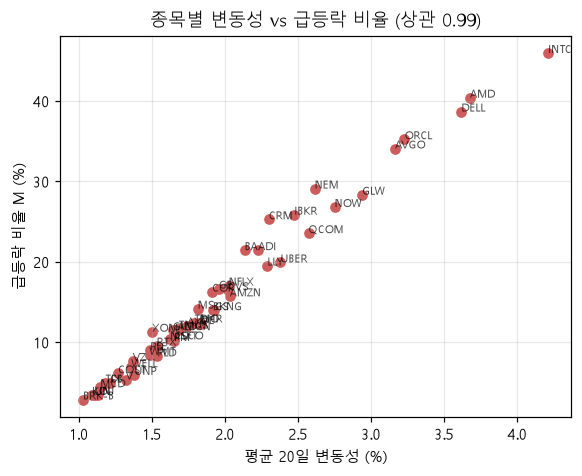

In [5]:
s = panel.groupby("symbol").agg(vol20=("vol20", "mean"), M=("M", "mean"))
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(s["vol20"] * 100, s["M"] * 100, color="indianred")
for sym, r in s.iterrows():
    ax.annotate(sym, (r["vol20"] * 100, r["M"] * 100), fontsize=7, alpha=0.7)
ax.set(title=f"종목별 변동성 vs 급등락 비율 (상관 {s.corr().iloc[0, 1]:.2f})",
       xlabel="평균 20일 변동성 (%)", ylabel="급등락 비율 M (%)")
plt.show()

label은 절대 수익률(±2.5%) 기준이라 변동성 정규화값(zgap)만 쓰면 안 됨. 같은 z=2라도 BRK-B는 +1%대, AMD는 +5%대임.
아래 표는 같은 zgap 구간 안에서도 변동성에 따라 M이 크게 다름을 보여 줌. 그래서 **절대값과 정규화값을 둘 다** 유지함.

In [6]:
t = panel.dropna(subset=["zgap", "vol20"]).copy()
t["zgap_bin"] = pd.cut(t["zgap"].abs(), [0, 0.5, 1, 2, np.inf])
t["vol_bin"] = pd.qcut(t["vol20"], 3, labels=["저변동", "중변동", "고변동"])
t.pivot_table(index="zgap_bin", columns="vol_bin", values="M", aggfunc="mean", observed=True)

vol_bin,저변동,중변동,고변동
zgap_bin,,,
"(0.0, 0.5]",0.0459,0.0927,0.2139
"(0.5, 1.0]",0.0791,0.2028,0.4453
"(1.0, 2.0]",0.1867,0.3934,0.6170
"(2.0, inf]",0.5879,0.7391,0.8817


## 3. 프리마켓 갭 기준선

갭 = (대상일 08:00 pre 봉 종가) ÷ (기준일 종가) − 1. 09:30 전에 알 수 있는 가장 직접적인 정보임.

### 그림: 육각 밀도 산점도 (hexbin)
점이 2만 개가 넘으면 일반 산점도는 점이 겹쳐서 어디에 많이 몰렸는지 안 보임.
hexbin은 **평면을 작은 육각형 칸으로 나누고 칸마다 들어간 점의 개수를 색으로 칠한 산점도**임.
진한 칸일수록 관측이 많음. 점선은 y = x(갭이 그대로 당일 수익률이 되는 경우)임.

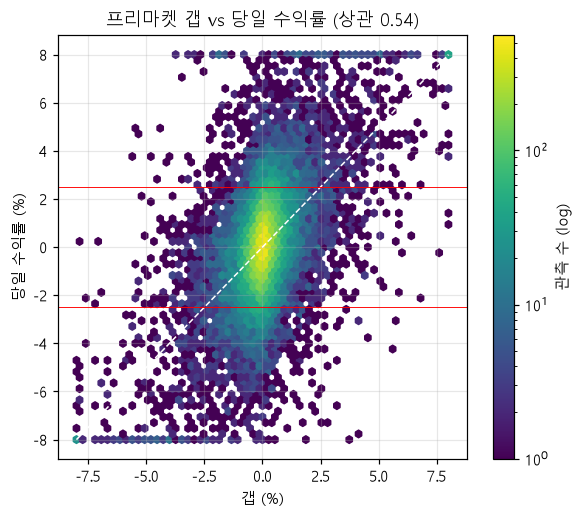

In [7]:
d = panel.dropna(subset=["gap_pct"])
fig, ax = plt.subplots(figsize=(6, 5))
hb = ax.hexbin(d["gap_pct"].clip(-8, 8), d["ret_pct"].clip(-8, 8), gridsize=60, bins="log", cmap="viridis")
ax.plot([-8, 8], [-8, 8], "w--", lw=1)
for v in (-2.5, 2.5):
    ax.axhline(v, color="r", lw=0.6)
fig.colorbar(hb, label="관측 수 (log)")
ax.set(title=f"프리마켓 갭 vs 당일 수익률 (상관 {d[['gap_pct', 'ret_pct']].corr().iloc[0, 1]:.2f})",
       xlabel="갭 (%)", ylabel="당일 수익률 (%)")
plt.show()

갭의 **크기**는 M을, **부호**는 방향을 얼마나 설명하는지 구간별 막대그래프로 봄.

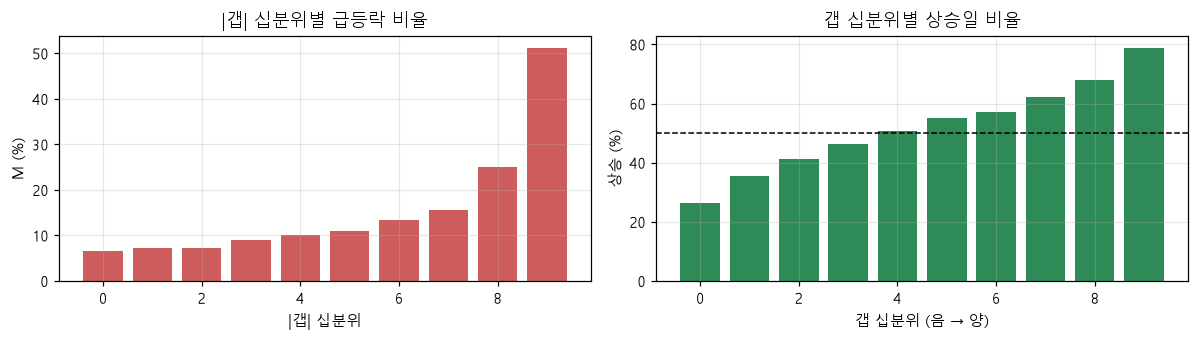

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
b = U.binned(d, "abs_gap", "M", q=10)
axes[0].bar(range(len(b)), b["M"] * 100, color="indianred")
axes[0].set(title="|갭| 십분위별 급등락 비율", xlabel="|갭| 십분위", ylabel="M (%)")
d2 = d.assign(up=(d["D"] > 0).astype(float))
b = U.binned(d2, "gap_pct", "up", q=10)
axes[1].bar(range(len(b)), b["up"] * 100, color="seagreen")
axes[1].axhline(50, color="k", lw=1, ls="--")
axes[1].set(title="갭 십분위별 상승일 비율", xlabel="갭 십분위 (음 → 양)", ylabel="상승 (%)")
plt.tight_layout()
plt.show()

### 갭 규칙의 score
`gap_rule(k)` = label_of(k × 갭%). k를 학습 구간(대상일 < 2026-01-01)에서 고르고, 그 뒤 구간에서 잼.
아래 선 그래프는 k를 바꿀 때 학습 구간 score가 어떻게 변하는지 보여 줌.

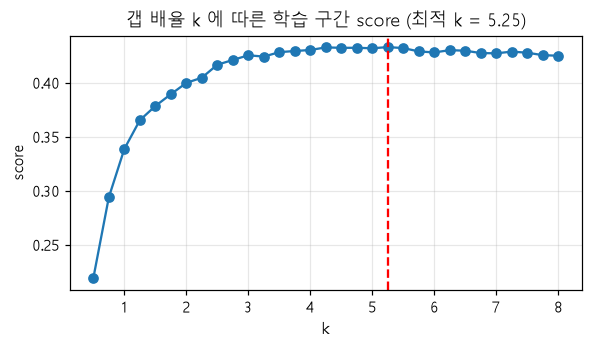

,score,accuracy,big_recall,big_prec,flip_rate
k=1.0,0.4149,0.3583,0.1922,0.6517,0.0144
k=5.25,0.5184,0.3022,0.6135,0.2678,0.1866


In [9]:
train, test = d[d["target"] < "2026-01-01"], d[d["target"] >= "2026-01-01"]
k, curve = U.fit_gap_rule(train)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(curve["k"], curve["score"], marker="o")
ax.axvline(k, color="r", ls="--")
ax.set(title=f"갭 배율 k 에 따른 학습 구간 score (최적 k = {k})", xlabel="k", ylabel="score")
plt.show()
gap_base = pd.DataFrame({f"k={kk}": U.score_ext(test["label"], U.gap_rule(test["gap_pct"], kk)) for kk in (1.0, k)}).T
gap_base[["score", "accuracy", "big_recall", "big_prec", "flip_rate"]]

## 4. 갭 이후 지속·반전

당일 로그수익률 = 갭 + 나머지(rest, 09:30 이후 움직임에 가까움)로 나눔.
갭과 당일 수익률의 상관 중 상당 부분은 "갭이 당일 수익률의 일부"라서 생기는 구조적인 상관임.
진짜 질문은 **갭이 생긴 뒤 가격이 같은 방향으로 더 가는가(지속), 되돌아오는가(반전)**임.

### 그림: 상자 그림 (box plot)
상자 그림은 **한 집단의 분포를 다섯 숫자로 요약한 그림**임. 상자의 아래·위 변은 25%·75% 지점,
상자 안의 선은 중앙값, 수염은 대부분의 값이 놓인 범위임. 여러 집단의 상자를 나란히 놓고 중앙값의 위치와 퍼짐을 비교함.
여기서는 갭 구간마다 rest(갭 이후 움직임)의 분포를 그림. 상자가 0선 위에 있으면 상승, 아래에 있으면 하락임.

,n,rest_mean,지속_비율,M
gap_bin,,,,
< -2.5,560,0.4168,0.4357,0.6321
-2.5~-1,1491,0.3379,0.4547,0.3233
-1~-0.3,4300,0.0483,0.4709,0.1309
±0.3,11660,-0.0078,0.4965,0.0776
0.3~1,5431,-0.0554,0.4938,0.1328
1~2.5,1936,-0.0669,0.4804,0.3197
> 2.5,645,-0.2376,0.4217,0.6527


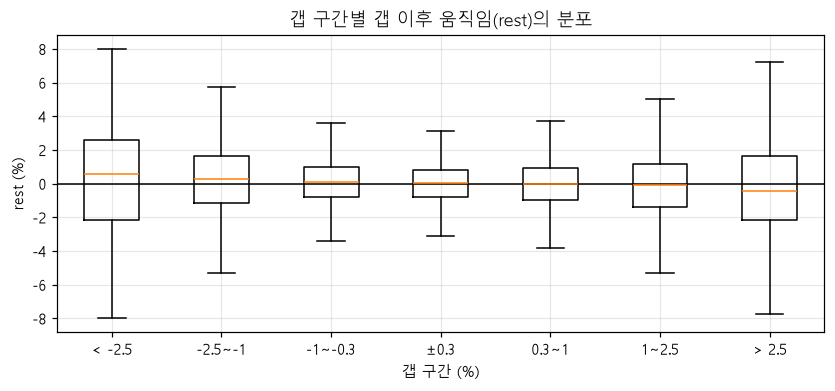

In [10]:
bins = [-np.inf, -2.5, -1, -0.3, 0.3, 1, 2.5, np.inf]
names = ["< -2.5", "-2.5~-1", "-1~-0.3", "±0.3", "0.3~1", "1~2.5", "> 2.5"]
d = d.assign(gap_bin=pd.cut(d["gap_pct"], bins, labels=names), rest_pct=d["rest"] * 100)
same = np.sign(d["rest"]) == np.sign(d["gap"])
summary = d.assign(same=same).groupby("gap_bin", observed=True).agg(
    n=("rest", "size"), rest_mean=("rest_pct", "mean"), 지속_비율=("same", "mean"), M=("M", "mean"))
display(summary)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.boxplot([d.loc[d["gap_bin"] == n, "rest_pct"].clip(-8, 8) for n in names], tick_labels=names, showfliers=False)
ax.axhline(0, color="k", lw=1)
ax.set(title="갭 구간별 갭 이후 움직임(rest)의 분포", xlabel="갭 구간 (%)", ylabel="rest (%)")
plt.show()

## 5. 시장 갭 / 잔차 갭

- 시장 갭 = 자기 자신을 뺀 다른 종목들 갭의 **중앙값**(leave-one-out). 실적 같은 한 종목의 사건에 흔들리지 않게 평균 대신 중앙값을 씀
- 잔차 갭 = 갭 − β × 시장 갭 (β는 과거 60일 rolling)

예: AMD 갭이 +4%여도 시장이 +3.5%면 잔차는 약 +0.5%. 시장이 0%인데 AMD만 +4%면 회사 고유의 사건일 가능성이 큼.

### 그림: 두 계열 선 그래프
같은 가로축(십분위) 위에 두 변수의 결과를 각각 선으로 그려 **어느 쪽이 y를 더 강하게 가르는지** 비교함.
선의 기울기가 가파를수록 그 변수가 급등락을 더 잘 구분함.

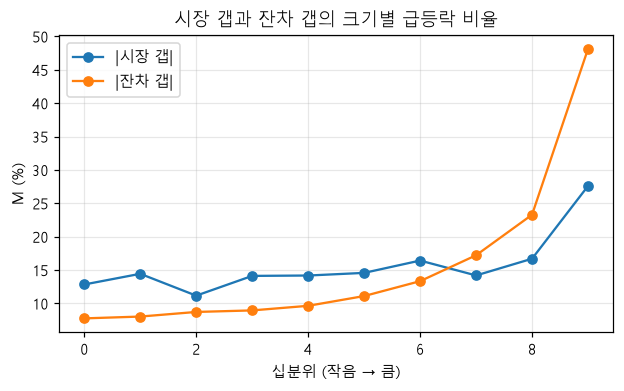

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
for col, lab in [("mkt_gap", "|시장 갭|"), ("resid_gap", "|잔차 갭|")]:
    b = U.binned(d.assign(a=d[col].abs()), "a", "M", q=10)
    ax.plot(range(len(b)), b["M"] * 100, marker="o", label=lab)
ax.set(title="시장 갭과 잔차 갭의 크기별 급등락 비율", xlabel="십분위 (작음 → 큼)", ylabel="M (%)")
ax.legend()
plt.show()

채점 환경에는 20종목만 있음. 그래서 시장 갭을 **무작위 20종목만으로 계산해도** 50종목 기준과 비슷한지 확인함.

In [12]:
rng = np.random.default_rng(0)
rows = []
for i in range(5):
    sub = d[d["symbol"].isin(rng.choice(d["symbol"].unique(), 20, replace=False))]
    m20 = U.loo_median(sub["gap"], sub["target"])
    rows.append(np.corrcoef(m20, sub["mkt_gap"])[0, 1])
pd.Series(rows, name="20종목 시장 갭 vs 50종목 시장 갭 상관").describe()[["mean", "min", "max"]]

mean   0.9574
min    0.9348
max    0.9674
Name: 20종목 시장 갭 vs 50종목 시장 갭 상관, dtype: float64